In [1]:
import sys
print(sys.executable)

C:\Users\tyler\miniconda3\envs\churn-env\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn

---

## EDA
Explore data, note anything interesting. Start with shape, data types, and missing values.

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [91]:
print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

A clean dataset - how lucky! 

### EDA Possible Issues
- TotalCharges field is stored as object (string) instead of float
- SeniorCitizen field is encoded as 0 and 1, but most other boolean fields are Yes/No
- 


Investigating why'TotalCharges' is not a float like 'MonthlyCharges'

In [59]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

'TotalCharges' values are stored as strings. Why?

In [74]:
# Check how many values can't be converted to a number
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()

np.int64(11)

In [76]:
# Verify that all 11 cases are because of a space
df[df['TotalCharges'] == ' '].shape[0]

11

11 values are ' ', which is why they weren't picked up as empty in `df.info`, and why the column isn't converting to float.

Could use mean imputation here but TotalCharges looks like MonthlyCharges * tenure, so calculate what these values should be

In [83]:
df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


These 11 cases are new customers who haven't been there a month yet and haven't been charged. So in this case I will put zeroes in TotalCharges because they are actually zero. Entering 0's in empty values can mislead the model, but I think it is warranted here

In [87]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [90]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum())

float64
0


## Issues Fixed
- TotalCharges: converted from object to float64. 11 empty strings replaced with 0 (new customers with tenure = 0, not actually missing data)
- SeniorCitizen: already numeric unlike other binary columns which use Yes/No
- Churn: currently stored as Yes/No text, will convert to 1/0 in preprocessing

Consider target variable distribution

In [49]:
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Dataset has somewhat imbalanced classes (73% no-churn and 27% churn) - Accuracy alone won't be a reliable metric. Will need to look at F1 score and possibly address imbalance during modeling. 

Look at numerical data first, and see how each relates to Churn

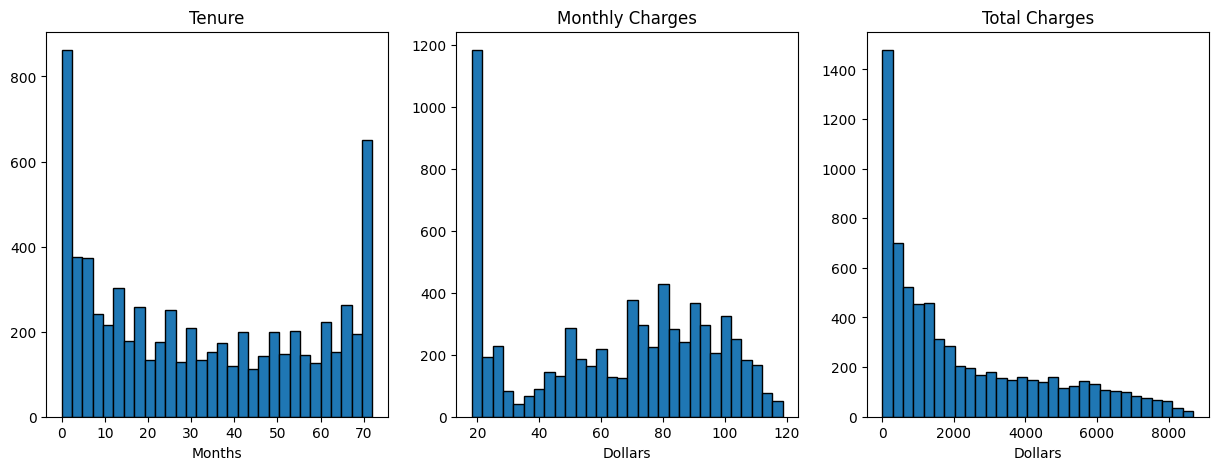

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['tenure'], bins=30, edgecolor='black')
axes[0].set_title('Tenure')
axes[0].set_xlabel('Months')

axes[1].hist(df['MonthlyCharges'], bins=30, edgecolor='black')
axes[1].set_title('Monthly Charges')
axes[1].set_xlabel('Dollars')

axes[2].hist(df['TotalCharges'], bins=30, edgecolor='black')
axes[2].set_title('Total Charges')
axes[2].set_xlabel('Dollars')

plt.show()

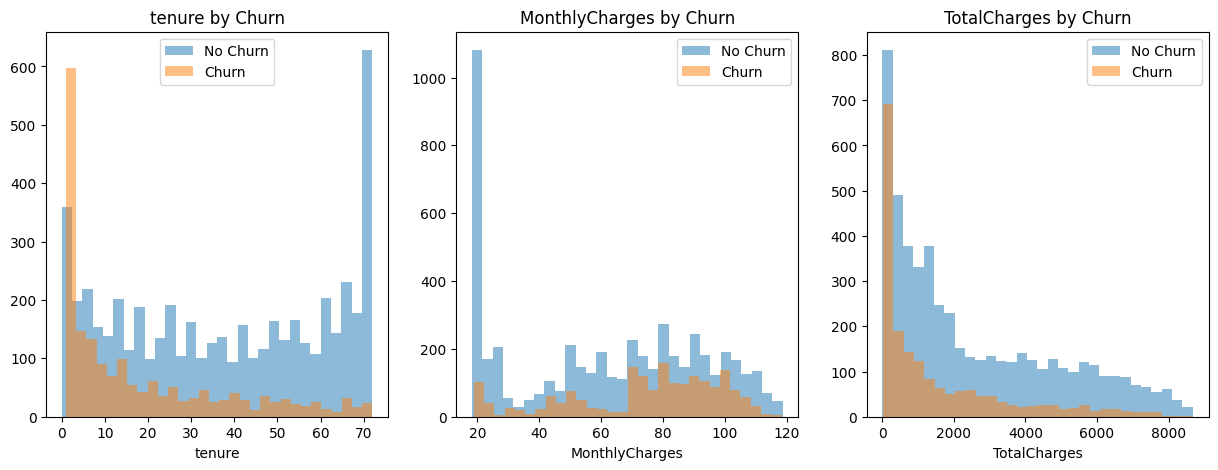

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]
    ax.hist(not_churned, bins=30, alpha=0.5, label='No Churn')
    ax.hist(churned, bins=30, alpha=0.5, label='Churn')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.legend()

plt.show()

## Numeric Feature Notes

**Tenure:**
- Bimodal dist. — lots of new customers and long term customers
- Strong relationship with churn — new customers churn at much higher rate, long term customers tend to stay
- Probably very important feature in model

**MonthlyCharges:**
- Customers with higher monthly charges tend to churn more (ratio of churn/no-churn around >70 compared to <70)
- Makes intuitive sense - customers paying higher monthly charge feel like value for price

**TotalCharges:**
- Right skewed dist. — may need to address in preprocessing
- Both churned and non-churned customers cluster at low total charges, likely because new customers have low total charges by definition regardless of churn
- Probably correlated with tenure  — may not add much independent information to model

Need to check correlations between numeric features before modeling to assess multicollinearity

Next look at categorical data

In [108]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [110]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values — {df[col].unique()}")

customerID: 7043 unique values — ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: 2 unique values — ['Female' 'Male']
Partner: 2 unique values — ['Yes' 'No']
Dependents: 2 unique values — ['No' 'Yes']
PhoneService: 2 unique values — ['No' 'Yes']
MultipleLines: 3 unique values — ['No phone service' 'No' 'Yes']
InternetService: 3 unique values — ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values — ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values — ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values — ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique values — ['No' 'Yes' 'No internet service']
Contract: 3 unique values — ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values — ['Yes' 'No']
PaymentMethod: 4 unique values — ['Electronic check' 'Ma

customerID column can be dropped since it is arbitrarily assigned and unique for each customer. Plotting all other fields groupby Churn to see which features have a strong relationship to churn

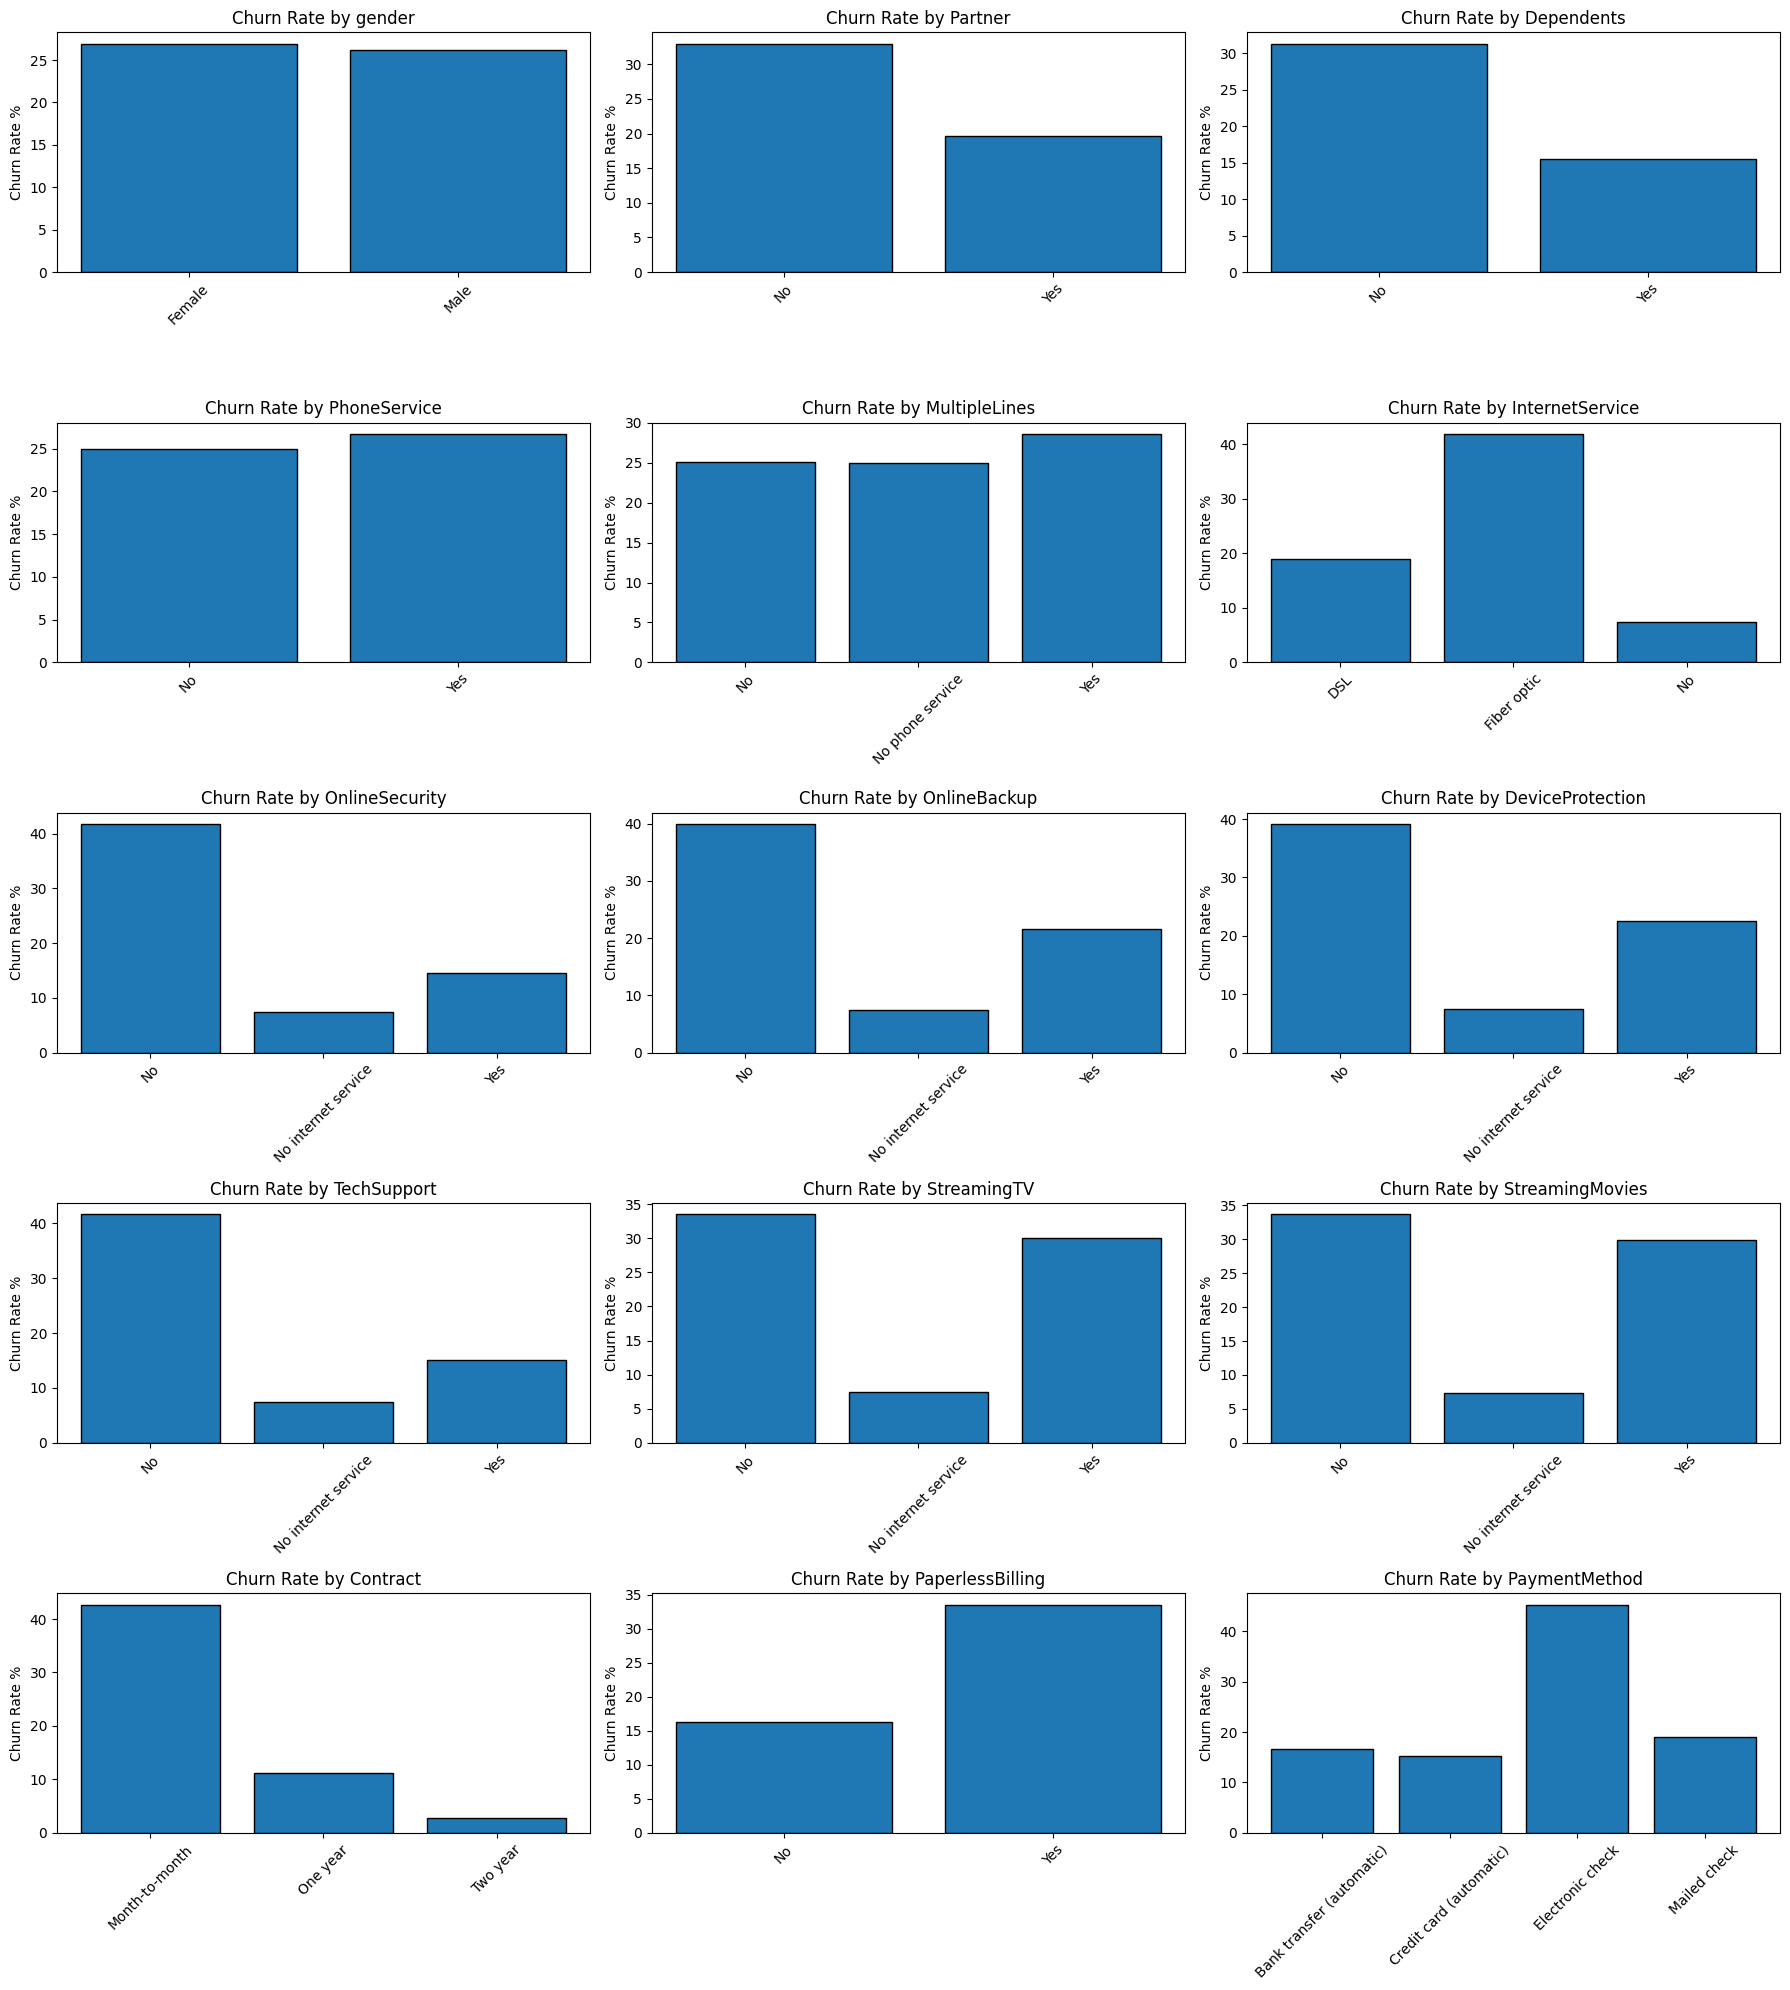

In [123]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    axes[i].bar(churn_rate.index, churn_rate.values, edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [124]:
for col in categorical_cols:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    print(churn_rate)

gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64
PhoneService
No     24.9
Yes    26.7
Name: Churn, dtype: float64
MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Name: Churn, dtype: float64
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn, dtype: float64
DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5
Name: Churn, dtype: float64
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64
StreamingTV
No       

## Categorical Feature Notes

**Strongest predictors of churn:**
- Contract type: month-to-month customers churn at 42.7% vs 2.8% for two year contracts
- Payment method: electronic check customers churn at 45.3% vs 15-19% for other methods
- Internet service: fiber optic customers churn at 41.9% vs 19% for DSL
- Additional services (OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection): 
  customers without these services churn at ~40%, those with them churn at ~15-22%. Suggesting customers that are more deeply embedded in the companys system are less likely to leave

**Weak predictors:**
- Gender and PhoneService show almost no relationship with churn

**Business insight:**
- Customers on long term contracts, enrolled in multiple services, and using 
  automatic payment methods are significantly less likely to churn
- Fiber optic customers show unusually high churn, which may be due to a 
  pricing or quality issue with that product
- Partner and Dependents show moderate relationship — customers with more personal commitments and stability in their lives seem less likely to churn

Looking at correlations between numeric features. Possibly address multicolinearity

In [125]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


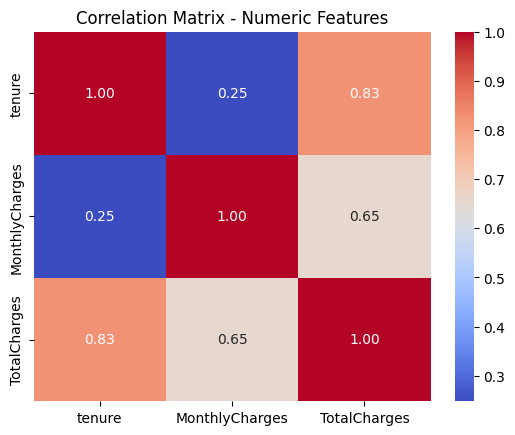

In [126]:
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Numeric Features')
plt.show()

Might drop TotalCharges, since it is strongly correlated with tenure.

Check for outliers

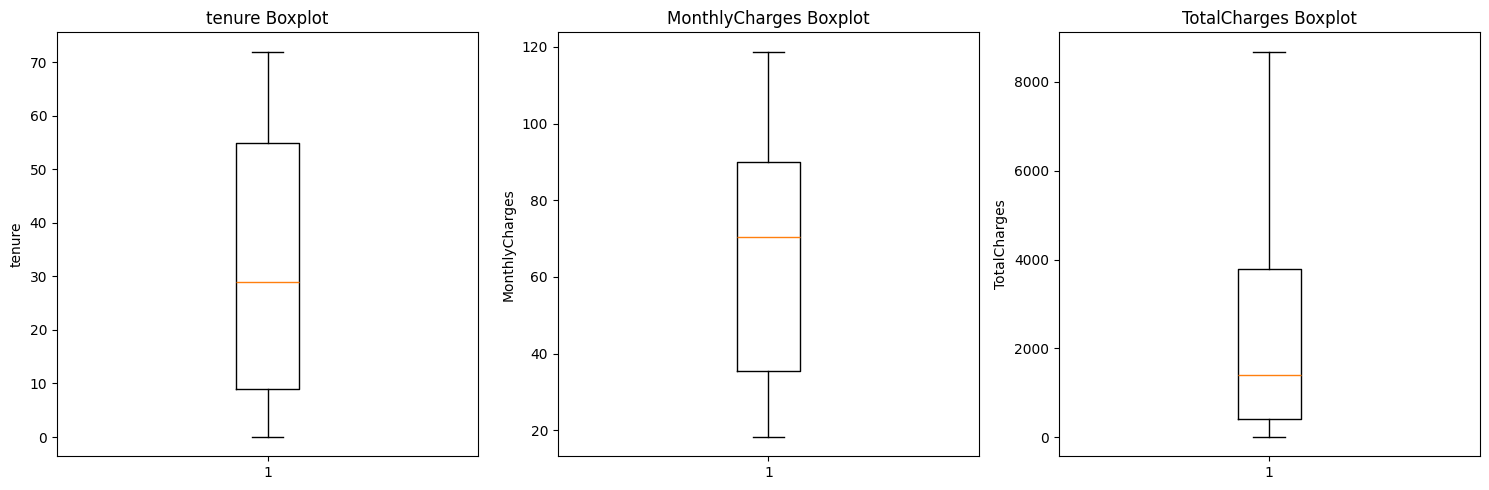

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.boxplot(df[col])
    ax.set_title(f'{col} Boxplot')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

Boxplots show no outliers in tenure, MonthlyCharges, or TotalCharges. No outlier treatment needed before modeling

In [130]:
print(df['SeniorCitizen'].value_counts())
print('\n')
churn_rate = df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(churn_rate)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64


## Interesting find on SeniorCitizen field
- Dataset is 84% non-senior (5901) and 16% senior (1142)
- Senior citizens churn at 41.7% vs 23.6% for non-seniors — almost 2x
- This will probably be a meaningful predictor and should be kept as a feature

## EDA Summary

**Data Quality:**
- 7043 rows, 21 columns
- No true missing values, but TotalCharges had 11 empty strings. Fixed by filling with 0 (these were new customers with tenure = 0, not truly missing data)
- TotalCharges was incorrectly stored as object datatype — converted to float64

**Numeric Features:**
- Tenure is bimodal — large groups of very new and very long term customers
- Higher MonthlyCharges associated with higher churn
- TotalCharges highly correlated with tenure (multicollinearity). Will probably drop TotalCharges and consider an engineered feature instead
- No outliers detected in any numeric features

**Categorical Features:**
- Strongest predictors of churn: Contract, PaymentMethod, InternetService, 
  OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection, SeniorCitizen
- Weakest predictors: gender, PhoneService (minimal churn rate difference)
- Month-to-month customers churn at 42.7% vs 2.8% for two year contracts (strongest single signal in the dataset)
- Electronic check customers churn at 45.3% vs 15-19% for automatic payment methods
- Fiber optic customers churn at 41.9% — maybe pricing or quality issue
- Customers without add-on services churn at ~40% vs ~15-22% with them (product stickiness effect)
- Senior citizens churn at 41.7% vs 23.6% for non seniors

**Things to do in Preprocessing:**
- Drop customerID — just an identifier, no predictive value
- Drop TotalCharges — highly correlated with tenure, redundant
- Consider engineered feature. Look at TotalCharges / tenure (average monthly spend)
- Convert Churn to binary for modeling
- Encode remaining categorical features as numeric
- Address class imbalance (73% No, 27% Yes) during modeling